In [181]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text

In [182]:
import sdv
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

print("Librerías importadas correctamente")
print("SDV version:", sdv.__version__)

Librerías importadas correctamente
SDV version: 1.37.0


In [183]:
from sqlalchemy import create_engine, text

In [184]:
# Configuración de la conexión a PostgreSQL
DB_USER = "postgres"
DB_PASSWORD = "123456"  
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "dw_ventas"

# Crear engine con SQLAlchemy
from sqlalchemy import create_engine, text

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

# Probar conexión
try:
    with engine.connect() as conn:
        resultado = conn.execute(text("SELECT version();"))
        version = resultado.fetchone()[0]
        print("Conexión exitosa")
        print(f"PostgreSQL: {version[:50]}...")
except Exception as e:
    print(f"Error de conexión: {e}")

Conexión exitosa
PostgreSQL: PostgreSQL 18.1 on x86_64-windows, compiled by msv...


In [185]:

# Script SQL corregido para crear las tablas del Data Warehouse
ddl_script = """
-- Dimensión Cliente
CREATE TABLE IF NOT EXISTS dim_cliente (
    cliente_id SERIAL PRIMARY KEY,
    nombre VARCHAR(100),
    edad INT,
    ciudad VARCHAR(80),
    region VARCHAR(60),
    segmento VARCHAR(40)
);

-- Dimensión Producto
CREATE TABLE IF NOT EXISTS dim_producto (
    producto_id SERIAL PRIMARY KEY,
    nombre VARCHAR(120),
    categoria VARCHAR(60),
    precio_unitario NUMERIC(10,2)
);

-- Dimensión Tiempo
CREATE TABLE IF NOT EXISTS dim_tiempo (
    tiempo_id SERIAL PRIMARY KEY,
    fecha DATE,
    anio INT,
    mes INT,
    trimestre INT,
    dia_semana VARCHAR(20)
);

-- Dimensión Región
CREATE TABLE IF NOT EXISTS dim_region (
    region_id SERIAL PRIMARY KEY,
    nombre VARCHAR(60),
    estado VARCHAR(60),
    pais VARCHAR(40)
);

-- Tabla de Hechos: Ventas
CREATE TABLE IF NOT EXISTS fact_ventas (
    venta_id SERIAL PRIMARY KEY,
    cliente_id INT REFERENCES dim_cliente(cliente_id),
    producto_id INT REFERENCES dim_producto(producto_id),
    tiempo_id INT REFERENCES dim_tiempo(tiempo_id),
    region_id INT REFERENCES dim_region(region_id),
    cantidad INT,
    monto_total NUMERIC(12,2),
    descuento NUMERIC(5,2)
);
"""

# Ejecutar el script SQL
try:
    with engine.begin() as conn:
        conn.execute(text(ddl_script))
    print("Tablas creadas exitosamente en PostgreSQL")
except Exception as e:
    print(f"Error al crear tablas: {e}")

Tablas creadas exitosamente en PostgreSQL


In [186]:


# DataFrame de clientes (corregido)
dfClientes = pd.DataFrame({
    "cliente_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "nombre": ["Brenda Mrtinez", "Luis Fernández", "Ana Rodríguez", "Carlos Martínez", 
               "Cristian Gómez", "Jorge Díaz", "Crescencio Sánchez", "Miguel Ramírez",
               "Adolfo Torres", "Pablo Mendoza"],
    "edad": [23, 33, 43, 28, 53, 56, 43, 56, 65, 40],
    "ciudad": ["Tuxtepec", "Oaxaca", "Veracruz", "Córdoba",
               "Puebla", "CDMX", "Guadalajara", "Monterrey",
               "Mérida", "Tijuana"],
    "region": ["Sur", "Sur", "Sur", "Sur",
               "Centro", "Centro", "Occidente", "Norte",
               "Sureste", "Norte"],
    "segmento": ["Minorista", "Mayorista", "Minorista", "Mayorista",
                 "Minorista", "Corporativo", "Corporativo", "Mayorista",
                 "Minorista", "Corporativo"]
})



In [187]:
dfClientes.head()

,cliente_id,nombre,edad,ciudad,region,segmento
0,1,Brenda Mrtinez,23,Tuxtepec,Sur,Minorista
1,2,Luis Fernández,33,Oaxaca,Sur,Mayorista
2,3,Ana Rodríguez,43,Veracruz,Sur,Minorista
3,4,Carlos Martínez,28,Córdoba,Sur,Mayorista
4,5,Cristian Gómez,53,Puebla,Centro,Minorista


In [188]:
# DataFrame base de productos
dfProductos = pd.DataFrame({
    "producto_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "nombre": ["Laptop HP", "Monitor LG", "Teclado Logitech", "Mouse Inalambrico",
               "Tablet Samsung", "Auriculares Sony", "Webcam Logitech", "Disco SSD 1TB"],
    "categoria": ["Computadoras", "Periféricos", "Periféricos", "Periféricos",
                  "Moviles", "Audio", "Perifericos", "Almacenamiento"],
    "precio_unitario": [15000.00, 4500.00, 850.00, 350.00,
                        9000.00, 1200.00, 780.00, 1800.00]
})

In [189]:
dfProductos.head()

,producto_id,nombre,categoria,precio_unitario
0,1,Laptop HP,Computadoras,15000.0
1,2,Monitor LG,Periféricos,4500.0
2,3,Teclado Logitech,Periféricos,850.0
3,4,Mouse Inalambrico,Periféricos,350.0
4,5,Tablet Samsung,Moviles,9000.0


In [190]:
# DataFrame de dimensión Tiempo (últimos 12 meses)
fechas = pd.date_range(start="2024-01-01", end="2024-12-31", freq="ME")  

dfTiempo = pd.DataFrame({
    "tiempo_id": range(1, len(fechas) + 1),
    "fecha": fechas,
    "anio": fechas.year,
    "mes": fechas.month,
    "trimestre": fechas.quarter,
    "dia_semana": fechas.day_name()
})

In [191]:
dfTiempo.head()

,tiempo_id,fecha,anio,mes,trimestre,dia_semana
0,1,2024-01-31,2024,1,1,Wednesday
1,2,2024-02-29,2024,2,1,Thursday
2,3,2024-03-31,2024,3,1,Sunday
3,4,2024-04-30,2024,4,2,Tuesday
4,5,2024-05-31,2024,5,2,Friday


In [192]:
# DataFrame de dimensión Region
dfRegion = pd.DataFrame({
    "region_id": [1, 2, 3, 4, 5],
    "nombre": ["Sur", "Centro", "Occidente", "Norte", "Sureste"],
    "estado": ["Oaxaca", "CDMX", "Jalisco", "Nuevo León", "Yucatán"],
    "pais": ["México"] * 5
})

In [193]:
dfRegion.head()

,region_id,nombre,estado,pais
0,1,Sur,Oaxaca,México
1,2,Centro,CDMX,México
2,3,Occidente,Jalisco,México
3,4,Norte,Nuevo León,México
4,5,Sureste,Yucatán,México


In [194]:
# Entrenar el synthesizer (necesario antes de generar datos)
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

# Usar TUS clientes (los que ya pegaste arriba)
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(dfClientes)
synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(dfClientes)

print("Synthesizer entrenado correctamente")

C:\Users\yonat\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\yonat\anaconda3\Lib\site-packages\sdv\single_table\base.py:138: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



Synthesizer entrenado correctamente


In [195]:

# Generar 90 clientes sintéticos
clientes_sinteticos = synthesizer.sample(num_rows=90)
clientes_sinteticos.head()

,cliente_id,nombre,edad,ciudad,region,segmento
0,16169768,Pablo Mendoza,49,Tijuana,Centro,Corporativo
1,4918803,Ana Rodríguez,36,Córdoba,Sur,Mayorista
2,1900081,Adolfo Torres,30,Tijuana,Sur,Corporativo
3,531516,Cristian Gómez,41,Puebla,Centro,Minorista
4,10211768,Ana Rodríguez,42,Oaxaca,Occidente,Corporativo


In [196]:
clientes_sinteticos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   cliente_id  90 non-null     int64 
 1   nombre      90 non-null     object
 2   edad        90 non-null     int64 
 3   ciudad      90 non-null     object
 4   region      90 non-null     object
 5   segmento    90 non-null     object
dtypes: int64(2), object(4)
memory usage: 4.3+ KB


In [197]:
clientes_sinteticos.describe(include = "all")

,cliente_id,nombre,edad,ciudad,region,segmento
count,9.000000e+01,90,90.000000,90,90,90
unique,NaN,10,NaN,10,5,3
top,NaN,Brenda Mrtinez,NaN,Oaxaca,Sur,Minorista
freq,NaN,11,NaN,16,41,34
mean,8.596829e+06,NaN,43.655556,NaN,NaN,NaN
std,4.653282e+06,NaN,12.747470,NaN,NaN,NaN
min,4.660500e+04,NaN,28.000000,NaN,NaN,NaN
25%,5.066923e+06,NaN,31.250000,NaN,NaN,NaN
50%,8.956428e+06,NaN,42.000000,NaN,NaN,NaN
75%,1.266882e+07,NaN,56.000000,NaN,NaN,NaN


In [198]:
# Importar QualityReport
from sdmetrics.reports.single_table import QualityReport

# Generar el reporte de calidad
report = QualityReport()
report.generate(
    real_data=dfClientes,
    synthetic_data=clientes_sinteticos,
    metadata=metadata.to_dict()
)

print("Reporte de calidad generado")

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 6/6 [00:00<00:00, 742.05it/s]|
Column Shapes Score: 88.89%

(2/2) Evaluating Column Pair Trends: |██████████| 15/15 [00:00<00:00, 153.18it/s]|
Column Pair Trends Score: 33.44%

Overall Score (Average): 61.17%

Reporte de calidad generado


In [199]:
# Paso 1: Reemplazar la tabla de hechos 
dfVentas.to_sql("fact_ventas", engine, if_exists="replace", index=False)

# Paso 2: Ahora reemplazar las dimensiones 
dfClientes.to_sql("dim_cliente", engine, if_exists="replace", index=False)
dfProductos.to_sql("dim_producto", engine, if_exists="replace", index=False)
dfTiempo.to_sql("dim_tiempo", engine, if_exists="replace", index=False)
dfRegion.to_sql("dim_region", engine, if_exists="replace", index=False)

print("Tablas reemplazadas correctamente")

Tablas reemplazadas correctamente


In [200]:
# Crear el DataFrame de ventas
import numpy as np

np.random.seed(42)

dfVentas = pd.DataFrame({
    "venta_id": range(1, 501),
    "cliente_id": np.random.randint(1, 11, 500),
    "producto_id": np.random.randint(1, 9, 500),
    "tiempo_id": np.random.randint(1, 13, 500),
    "region_id": np.random.randint(1, 6, 500),
    "cantidad": np.random.randint(1, 10, 500),
    "monto_total": np.random.randint(100, 10000, 500),
    "descuento": np.random.randint(0, 25, 500)
})

print("dfVentas creado correctamente")
print(f" Total de ventas: {len(dfVentas)}")

# Paso 1: Reemplazar la tabla de hechos
dfVentas.to_sql("fact_ventas", engine, if_exists="replace", index=False)
print("fact_ventas reemplazada")

# Paso 2: Reemplazar las dimensiones
dfClientes.to_sql("dim_cliente", engine, if_exists="replace", index=False)
print("dim_cliente reemplazada")

dfProductos.to_sql("dim_producto", engine, if_exists="replace", index=False)
print(" dim_producto reemplazada")

dfTiempo.to_sql("dim_tiempo", engine, if_exists="replace", index=False)
print("dim_tiempo reemplazada")

dfRegion.to_sql("dim_region", engine, if_exists="replace", index=False)
print("dim_region reemplazada")

print("\n TODAS LAS TABLAS CARGADAS CORRECTAMENTE")

dfVentas creado correctamente
 Total de ventas: 500
fact_ventas reemplazada
dim_cliente reemplazada
 dim_producto reemplazada
dim_tiempo reemplazada
dim_region reemplazada

 TODAS LAS TABLAS CARGADAS CORRECTAMENTE


In [201]:
# Cargar tabla de hechos
dfVentas.to_sql("fact_ventas", engine, if_exists="append", index=False)

print("\n Tabla de hechos cargada correctamente")
print(f" {len(dfVentas)} registros insertados en fact_ventas")


 Tabla de hechos cargada correctamente
 500 registros insertados en fact_ventas


In [202]:
# CONSULTAS SQL Y ANÁLISIS CON PANDAS

# Consulta 1: Ventas totales por región
query_region = """
SELECT 
    r.nombre AS region,
    SUM(v.monto_total) AS total_ventas,
    COUNT(v.venta_id) AS num_transacciones
FROM fact_ventas v
JOIN dim_region r ON v.region_id = r.region_id
GROUP BY r.nombre
ORDER BY total_ventas DESC;
"""

dfVentasRegion = pd.read_sql(query_region, engine)
print("VENTAS TOTALES POR REGIÓN:")
print(dfVentasRegion)

VENTAS TOTALES POR REGIÓN:
      region  total_ventas  num_transacciones
0  Occidente       1091800                204
1     Centro       1048542                206
2      Norte       1048252                192
3        Sur        987248                200
4    Sureste        944808                198


In [203]:
# Consulta 2: Productos más vendidos
query_productos = """
SELECT 
    p.nombre AS producto,
    p.categoria AS categoria,
    SUM(v.cantidad) AS unidades_vendidas,
    SUM(v.monto_total) AS ingresos_totales
FROM fact_ventas v
JOIN dim_producto p ON v.producto_id = p.producto_id
GROUP BY p.nombre, p.categoria
ORDER BY ingresos_totales DESC;
"""

dfTopProductos = pd.read_sql(query_productos, engine)
print("PRODUCTOS MÁS VENDIDOS:")
print(dfTopProductos)

PRODUCTOS MÁS VENDIDOS:
            producto       categoria  unidades_vendidas  ingresos_totales
0          Laptop HP    Computadoras                760            751554
1         Monitor LG     Periféricos                602            689130
2     Tablet Samsung         Moviles                754            684548
3    Webcam Logitech     Perifericos                624            652242
4   Teclado Logitech     Periféricos                604            637894
5   Auriculares Sony           Audio                580            612948
6  Mouse Inalambrico     Periféricos                546            579284
7      Disco SSD 1TB  Almacenamiento                450            513050


In [204]:
# Consulta 3: Ventas por mes (tendencia anual)
query_mes = """
SELECT 
    t.mes AS mes,
    t.trimestre AS trimestre,
    SUM(v.monto_total) AS ventas_mensuales
FROM fact_ventas v
JOIN dim_tiempo t ON v.tiempo_id = t.tiempo_id
GROUP BY t.mes, t.trimestre
ORDER BY t.mes;
"""

dfVentasMes = pd.read_sql(query_mes, engine)
print("VENTAS POR MES (TENDENCIA ANUAL):")
print(dfVentasMes)

VENTAS POR MES (TENDENCIA ANUAL):
    mes  trimestre  ventas_mensuales
0     1          1            391732
1     2          1            415736
2     3          1            418436
3     4          2            405986
4     5          2            470590
5     6          2            552020
6     7          3            458748
7     8          3            555148
8     9          3            353568
9    10          4            411012
10   11          4            407600
11   12          4            280074


In [205]:
# Consulta 4: Ventas por segmento de cliente
query_segmento = """
SELECT 
    c.segmento AS segmento,
    COUNT(DISTINCT v.cliente_id) AS clientes_activos,
    SUM(v.monto_total) AS total_ventas
FROM fact_ventas v
JOIN dim_cliente c ON v.cliente_id = c.cliente_id
GROUP BY c.segmento
ORDER BY total_ventas DESC;
"""

dfSegmento = pd.read_sql(query_segmento, engine)
print("VENTAS POR SEGMENTO DE CLIENTE:")
print(dfSegmento)

VENTAS POR SEGMENTO DE CLIENTE:
      segmento  clientes_activos  total_ventas
0    Minorista                 4       2066836
1  Corporativo                 3       1607724
2    Mayorista                 3       1446090


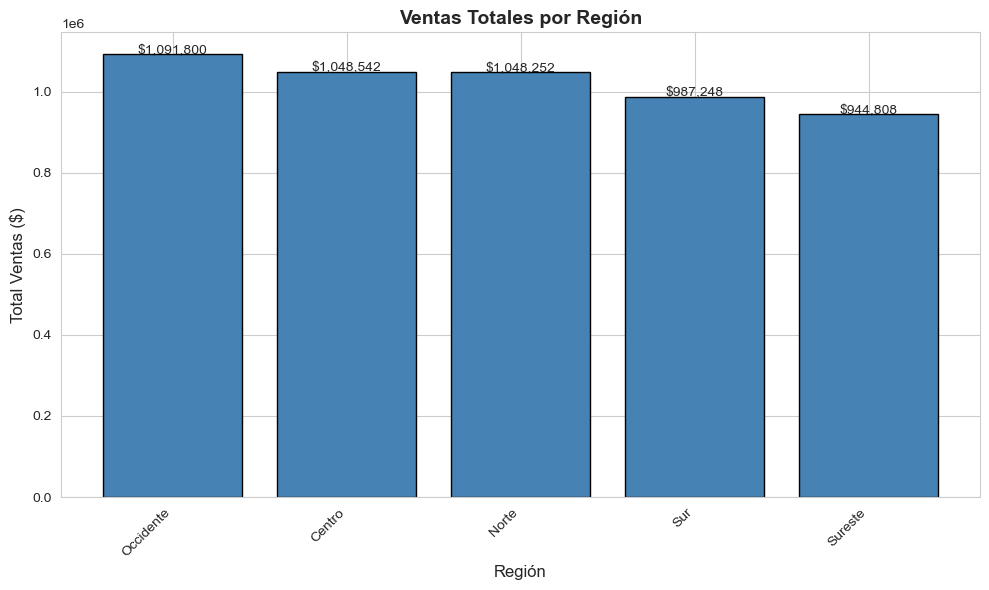

In [206]:
# GRÁFICA DE BARRAS: VENTAS TOTALES POR REGIÓN
# 

import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Crear gráfica de barras
plt.bar(dfVentasRegion['region'], dfVentasRegion['total_ventas'], 
        color='steelblue', edgecolor='black')

# Títulos y etiquetas
plt.title('Ventas Totales por Región', fontsize=14, fontweight='bold')
plt.xlabel('Región', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)

# Rotar etiquetas del eje X si es necesario
plt.xticks(rotation=45, ha='right')

# Agregar valores en la parte superior de las barras
for i, v in enumerate(dfVentasRegion['total_ventas']):
    plt.text(i, v + 1000, f'${v:,.0f}', ha='center', fontsize=10)

# Mostrar gráfica
plt.tight_layout()
plt.show()

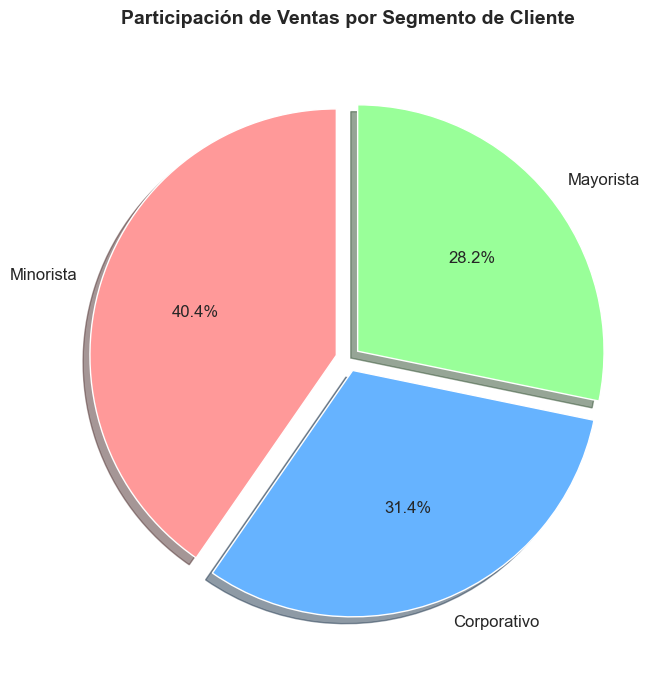

In [207]:

# GRÁFICA DE PASTEL: VENTAS POR SEGMENTO DE CLIENTE

import matplotlib.pyplot as plt

# Datos (asegúrate que dfSegmento ya existe)
segmentos = dfSegmento['segmento']
ventas = dfSegmento['total_ventas']

# Colores para cada segmento
colores = ['#ff9999', '#66b3ff', '#99ff99']

# Crear gráfica de pastel
plt.figure(figsize=(8, 8))
plt.pie(ventas, labels=segmentos, autopct='%1.1f%%', 
        startangle=90, colors=colores,
        explode=(0.05, 0.05, 0.05),  # Separar ligeramente las rebanadas
        shadow=True, textprops={'fontsize': 12})

# Título
plt.title('Participación de Ventas por Segmento de Cliente', 
          fontsize=14, fontweight='bold', pad=20)

plt.show()

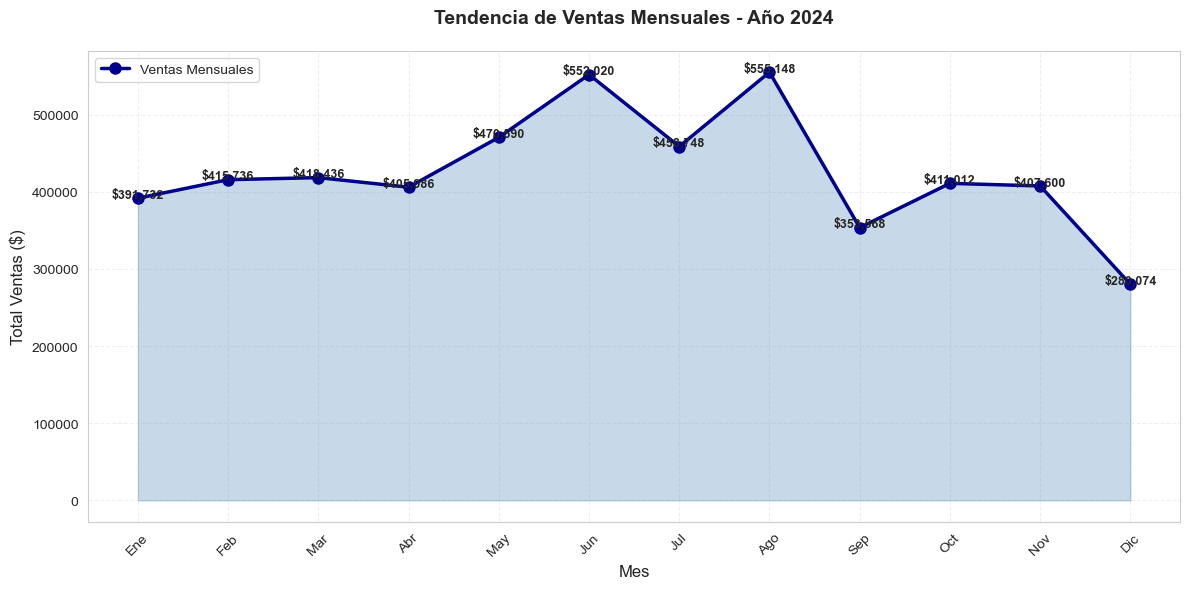

In [208]:

# GRÁFICA DE LÍNEAS CON ÁREA: TENDENCIA DE VENTAS MENSUALES 2024

import matplotlib.pyplot as plt
import numpy as np

# Datos (asegúrate que dfVentasMes ya existe)
meses = dfVentasMes['mes']
ventas = dfVentasMes['ventas_mensuales']

# Nombres de los meses
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
                 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

plt.figure(figsize=(12, 6))

# Llenar el área debajo de la línea
plt.fill_between(meses, ventas, alpha=0.3, color='steelblue')

# Línea de tendencia
plt.plot(meses, ventas, marker='o', linewidth=2.5, markersize=8, 
         color='darkblue', label='Ventas Mensuales')

# Títulos y etiquetas
plt.title('Tendencia de Ventas Mensuales - Año 2024', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Total Ventas ($)', fontsize=12)

# Configurar eje X con nombres de meses
plt.xticks(meses, nombres_meses, rotation=45)

# Agregar cuadrícula
plt.grid(True, alpha=0.3, linestyle='--')

# Agregar valores en los puntos
for i, (x, y) in enumerate(zip(meses, ventas)):
    plt.text(x, y + 500, f'${y:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Leyenda
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

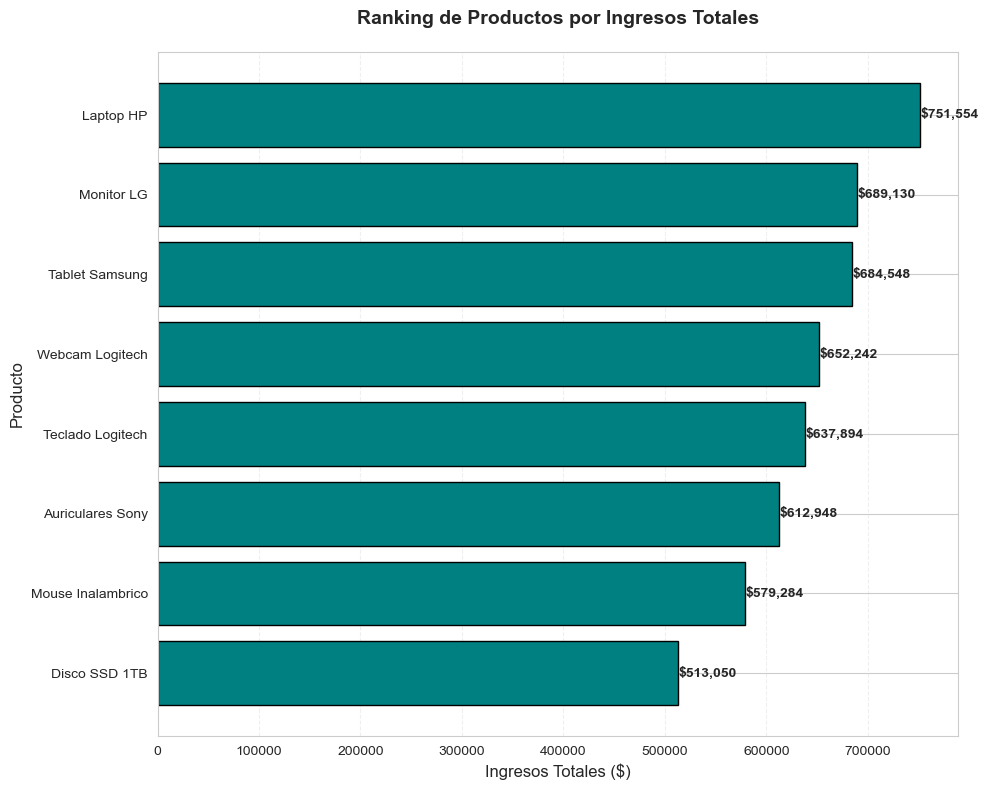

In [209]:
# GRÁFICA DE BARRAS HORIZONTALES: TOP PRODUCTOS POR INGRESOS

import matplotlib.pyplot as plt

# Datos (asegúrate que dfTopProductos ya existe)
# Tomamos los primeros 8 productos (o todos los que tengas)
top_productos = dfTopProductos.head(8)  # Top 8 productos
productos = top_productos['producto']
ingresos = top_productos['ingresos_totales']

# Crear gráfica de barras horizontales
plt.figure(figsize=(10, 8))

# Barras horizontales
barras = plt.barh(productos, ingresos, color='teal', edgecolor='black')

# Títulos y etiquetas
plt.title('Ranking de Productos por Ingresos Totales', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ingresos Totales ($)', fontsize=12)
plt.ylabel('Producto', fontsize=12)

# Agregar valores al final de cada barra
for barra in barras:
    ancho = barra.get_width()
    plt.text(ancho + 500, barra.get_y() + barra.get_height()/2, 
             f'${ancho:,.0f}', va='center', ha='left', fontsize=10, fontweight='bold')

# Invertir orden (el de mayores ingresos arriba)
plt.gca().invert_yaxis()

# Cuadrícula en el eje X
plt.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()